In [ ]:
#(1)
'''A ccompanyompany wants to predict employee productivity scores to improve workforce planning and
training programs. You are hired as a Data Scientist to build a multivariate linear regression model
that predicts an employee’s Productivity Score based on multiple work-related factors. '''

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
data = {
    "Experience": [2,5,1,8,4,10,3,6,7,2],
    "Training_Hours": [40,60,20,80,50,90,30,70,75,25],
    "Working_Hours": [38,42,35,45,40,48,37,44,46,36],
    "Projects": [3,6,2,8,5,9,4,7,7,3],
    "Productivity": [62,78,55,88,72,92,65,82,85,60]
}
df = pd.DataFrame(data)
X = df[["Experience", "Training_Hours", "Working_Hours", "Projects"]]
y = df["Productivity"]
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print(" Model trained successfully!\n")

print(" Model Coefficients:")
print("Experience:", model.coef_[0])
print("Training Hours:", model.coef_[1])
print("Working Hours:", model.coef_[2])
print("Projects:", model.coef_[3])
print("\n Intercept:", model.intercept_)
#  Model Evaluation (Check Overfitting)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("\n Model Performance:")
print("R² Score:", round(r2, 3))
#  Dynamic Input from User
print("\nEnter New Employee Details to Predict Productivity Score:\n")
exp = float(input("Enter Experience (years): "))
train = float(input("Enter Training Hours: "))
work = float(input("Enter Working Hours: "))
proj = float(input("Enter Number of Projects: "))
# Create dataframe for prediction
new_data = pd.DataFrame([[exp, train, work, proj]],
                        columns=["Experience", "Training_Hours", "Working_Hours", "Projects"])
predicted_score = model.predict(new_data)[0]
print("\n Predicted Productivity Score:", round(predicted_score, 2))

 Model trained successfully!

 Model Coefficients:
Experience: -0.26365795724465013
Training Hours: 0.2726840855106887
Working Hours: -1.0855106888361021
Projects: 4.885985748218523

 Intercept: 78.16864608076

 Model Performance:
R² Score: 0.315

Enter New Employee Details to Predict Productivity Score:

Enter Experience (years): 2
Enter Training Hours: 40
Enter Working Hours: 38
Enter Number of Projects: 3

 Predicted Productivity Score: 61.96


In [ ]:
df.corr()

,Experience,Training_Hours,Working_Hours,Projects,Productivity
Experience,1.000000,0.969810,0.973178,0.988194,0.981991
Training_Hours,0.969810,1.000000,0.993132,0.977151,0.987045
Working_Hours,0.973178,0.993132,1.000000,0.974701,0.985684
Projects,0.988194,0.977151,0.974701,1.000000,0.995696
Productivity,0.981991,0.987045,0.985684,0.995696,1.000000


In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
print("\n--- Which factor most strongly impacts productivity? ---")
feature_names = X.columns
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_,
    "Absolute_Impact": np.abs(model.coef_)
}).sort_values(by="Absolute_Impact", ascending=False)

print(coef_df)

most_impactful = coef_df.iloc[0]["Feature"]
print(f"\nMost strongly impacting factor: {most_impactful}")



--- Which factor most strongly impacts productivity? ---
          Feature  Coefficient  Absolute_Impact
3        Projects     4.885986         4.885986
2   Working_Hours    -1.085511         1.085511
1  Training_Hours     0.272684         0.272684
0      Experience    -0.263658         0.263658

Most strongly impacting factor: Projects


In [ ]:
#  How does training affect productivity?
print("\n--How does training affect productivity? ---")

training_coef = coef_df[coef_df["Feature"] == "Training_Hours"]["Coefficient"].values[0]
print(f"Training Hours coefficient: {training_coef:.4f}")

if training_coef > 0:#Training ↑ → Productivity ↑
    print("Interpretation: Training has a positive effect on productivity.")
elif training_coef < 0:
    print("Interpretation: Training has a negative effect on productivity.")
else:
    print("Interpretation: Training has no effect on productivity.")


--How does training affect productivity? ---
Training Hours coefficient: 0.2727
Interpretation: Training has a positive effect on productivity.


1. Which factor most strongly impacts productivity?

-Productivity increases significantly when projects increase from the above model coefficients it having high value so that it stobgly impacts.

2. How does training affect productivity?

-More training hours → higher productivity

3. Should the company increase training hours or working hours?

-  Training improves skills → long-term productivity  

   Working hours gives smaller improvement



4.What happens if Working Hours increase beyond optimal limits?

-Productivity may decrease after a point

Due to:

fatigue  

burnout  

reduced efficiency

5. Can productivity ever decrease with more experience?

-Yes, it can decrease due to:

 outdated skills  

 lack of motivation  

 resistance to change

6.How would you detect overfitting in this model?

-Training performance vs Testing performance

Q7: Suggest one new feature to improve prediction accuracy

-Skill Level / Performance Rating

In [ ]:
#(2)
'''Credit Card Fraud Detection'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
data = {
    "TransactionID": [1,2,3,4,5,6,7,8,9,10],
    "Amount": [1200,50,5000,200,1500,75,3200,40,2100,60],
    "TimeSinceLastTxn": [2,24,1,48,3,72,2,96,5,120],
    "LocationChange": [1,0,1,0,1,0,1,0,1,0],
    "AvgTxnAmount": [500,200,450,300,700,150,400,100,600,120],
    "IsForeignTransaction": [1,0,1,0,1,0,1,0,1,0],
    "IsHighRiskCountry": [1,0,1,0,0,0,1,0,1,0],
    "CardPresent": [0,1,0,1,0,1,0,1,0,1],
    "IsFraud": [1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)
print("Dataset:\n")
print(df)
X = df.drop(columns=["TransactionID", "IsFraud"])
y = df["IsFraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Train logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

Dataset:

   TransactionID  Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  \
0              1    1200                 2               1           500   
1              2      50                24               0           200   
2              3    5000                 1               1           450   
3              4     200                48               0           300   
4              5    1500                 3               1           700   
5              6      75                72               0           150   
6              7    3200                 2               1           400   
7              8      40                96               0           100   
8              9    2100                 5               1           600   
9             10      60               120               0           120   

   IsForeignTransaction  IsHighRiskCountry  CardPresent  IsFraud  
0                     1                  1            0        1  
1                  

LogisticRegression()


Intercept:
0.512968316779262

Coefficients:
Amount: 0.3126
TimeSinceLastTxn: -0.3741
LocationChange: 0.4879
AvgTxnAmount: 0.4026
IsForeignTransaction: 0.4879
IsHighRiskCountry: 0.3278
CardPresent: -0.4879

Logistic Regression Equation:
log(p / (1-p)) = 0.5130 + (0.3126 * Amount) + (-0.3741 * TimeSinceLastTxn) + (0.4879 * LocationChange) + (0.4026 * AvgTxnAmount) + (0.4879 * IsForeignTransaction) + (0.3278 * IsHighRiskCountry) + (-0.4879 * CardPresent)

Predictions with default threshold = 0.5:
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Feature Correlation Matrix:

                        Amount  TimeSinceLastTxn  LocationChange  \
Amo

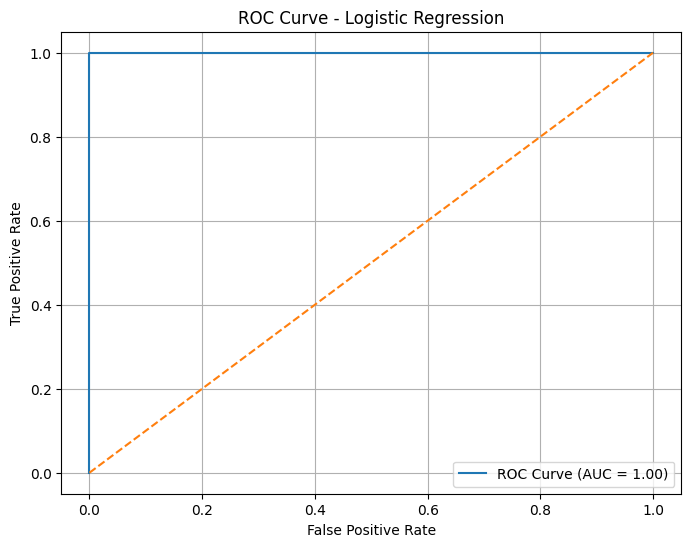


Threshold Tuning Results:

Threshold = 0.3
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]

Threshold = 0.4
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]

Threshold = 0.5
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]

Threshold = 0.6
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]

Threshold = 0.7
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]


In [ ]:
#Logistic regression equation
print("\nIntercept:")
print(model.intercept_[0])

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

print("\nLogistic Regression Equation:")
equation = f"log(p / (1-p)) = {model.intercept_[0]:.4f}"
for feature, coef in zip(X.columns, model.coef_[0]):
    equation += f" + ({coef:.4f} * {feature})"
print(equation)
#Predictions with default threshold = 0.5
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print("\nPredictions with default threshold = 0.5:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
# Correlation check
print("\nFeature Correlation Matrix:\n")
print(X.corr())
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()
print("\nThreshold Tuning Results:")
threshold_list = [0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in threshold_list:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    print(f"\nThreshold = {thresh}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))


In [ ]:
# Regularization comparison
models = {
    "L1 Regularization": LogisticRegression(penalty="l1", solver="liblinear"),
    "L2 Regularization": LogisticRegression(penalty="l2", solver="liblinear"),
}

for name, reg_model in models.items():
    reg_model.fit(X_train_scaled, y_train)
    y_prob_reg = reg_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_reg = (y_prob_reg >= 0.5).astype(int)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred_reg))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_reg))
    print("Coefficients:")
    for feature, coef in zip(X.columns, reg_model.coef_[0]):
        print(f"{feature}: {coef:.4f}")


L1 Regularization
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]
Coefficients:
Amount: 0.0000
TimeSinceLastTxn: 0.0000
LocationChange: 1.4445
AvgTxnAmount: 0.0000
IsForeignTransaction: 0.1807
IsHighRiskCountry: 0.0000
CardPresent: -0.1595

L2 Regularization
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 1]]
Coefficients:
Amount: 0.3006
TimeSinceLastTxn: -0.3882
LocationChange: 0.4874
AvgTxnAmount: 0.4163
IsForeignTransaction: 0.4874
IsHighRiskCountry: 0.3204
CardPresent: -0.4874


Problem statement – 3 Customer Segmentation (Retail / E-commerce)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.DataFrame({
    'CustomerID': [1,2,3,4,5,6,7,8,9,10],
    'Age': [22,25,47,52,23,45,33,35,60,28],
    'AnnualIncome': [15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    'SpendingScore': [39,81,6,20,77,15,50,55,10,70],
    'VisitsPerMonth': [4,6,2,3,5,2,4,5,1,6],
    'AvgOrderValue': [200,500,150,200,450,180,300,320,100,400]
})

print("Dataset:")
print(df)

Dataset:
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450
5           6   45         70000             15               2            180
6           7   33         40000             50               4            300
7           8   35         42000             55               5            320
8           9   60         80000             10               1            100
9          10   28         30000             70               6            400


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
data = {
    "TransactionID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Amount": [1200, 50, 5000, 200, 1500, 75, 3200, 40, 2100, 60],
    "TimeSinceLastTxn": [2, 24, 1, 48, 3, 72, 2, 96, 5, 120],
    "LocationChange": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    "AvgTxnAmount": [500, 200, 450, 300, 700, 150, 400, 100, 600, 120],
    "IsForeignTransaction": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    "IsHighRiskCountry": [1, 0, 1, 0, 0, 0, 1, 0, 1, 0],
    "CardPresent": [0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    "IsFraud": [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)
X = df.drop(columns=["TransactionID", "IsFraud"])
y = df["IsFraud"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy on Test Data:", accuracy)
print("\nEnter new transaction details to predict fraud or legitimate:")
amount = float(input("Enter Amount: "))
time_since_last_txn = float(input("Enter Time Since Last Transaction (in hours): "))
location_change = int(input("Enter Location Change (0 = No, 1 = Yes): "))
avg_txn_amount = float(input("Enter Average Transaction Amount: "))
is_foreign = int(input("Enter Is Foreign Transaction (0 = No, 1 = Yes): "))
is_high_risk = int(input("Enter Is High Risk Country (0 = No, 1 = Yes): "))
card_present = int(input("Enter Card Present (0 = No, 1 = Yes): "))
new_data = pd.DataFrame([{
    "Amount": amount,
    "TimeSinceLastTxn": time_since_last_txn,
    "LocationChange": location_change,
    "AvgTxnAmount": avg_txn_amount,
    "IsForeignTransaction": is_foreign,
    "IsHighRiskCountry": is_high_risk,
    "CardPresent": card_present
}])
prediction = model.predict(new_data)[0]
probability = model.predict_proba(new_data)[0][1]
if prediction == 1:
    print("\nPrediction: Fraud")
else:
    print("\nPrediction: Legitimate")
print("Fraud Probability:", round(probability, 4))

Model Accuracy on Test Data: 1.0

Enter new transaction details to predict fraud or legitimate:
Enter Amount: 1200
Enter Time Since Last Transaction (in hours): 2
Enter Location Change (0 = No, 1 = Yes): 1
Enter Average Transaction Amount: 500
Enter Is Foreign Transaction (0 = No, 1 = Yes): 1
Enter Is High Risk Country (0 = No, 1 = Yes): 1
Enter Card Present (0 = No, 1 = Yes): 0

Prediction: Fraud
Fraud Probability: 1.0


In [ ]:
print("\nNull values:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())


Null values:
CustomerID        0
Age               0
AnnualIncome      0
SpendingScore     0
VisitsPerMonth    0
AvgOrderValue     0
dtype: int64

Summary statistics:
       CustomerID        Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
count    10.00000  10.000000     10.000000      10.000000        10.00000   
mean      5.50000  37.000000  44000.000000      42.300000         3.80000   
std       3.02765  13.266499  23518.314376      28.488009         1.75119   
min       1.00000  22.000000  15000.000000       6.000000         1.00000   
25%       3.25000  25.750000  22500.000000      16.250000         2.25000   
50%       5.50000  34.000000  41000.000000      44.500000         4.00000   
75%       7.75000  46.500000  63750.000000      66.250000         5.00000   
max      10.00000  60.000000  80000.000000      81.000000         6.00000   

       AvgOrderValue  
count      10.000000  
mean      280.000000  
std       135.728487  
min       100.000000  
25%       185.000000  


In [ ]:

X = df[['Age', 'AnnualIncome', 'SpendingScore', 'VisitsPerMonth', 'AvgOrderValue']]

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardized Feature Values:")
print(X_scaled)


Standardized Feature Values:
[[-1.19182824 -1.2997821  -0.12210419  0.12038585 -0.62129481]
 [-0.95346259 -1.16532188  1.4319492   1.32424438  1.70856072]
 [ 0.79455216  0.71712116 -1.34314614 -1.08347268 -1.00960406]
 [ 1.19182824  0.94122152 -0.82512835 -0.48154341 -0.62129481]
 [-1.11237302 -1.07568174  1.28394411  0.72231512  1.32025147]
 [ 0.63564173  1.16532188 -1.0101347  -1.08347268 -0.77661851]
 [-0.31782086 -0.17928029  0.28490979  0.12038585  0.1553237 ]
 [-0.15891043 -0.08964014  0.46991614  0.72231512  0.3106474 ]
 [ 1.82746996  1.61352261 -1.19514106 -1.68540194 -1.39791332]
 [-0.71509694 -0.62748101  1.02493521  1.32424438  0.93194221]]


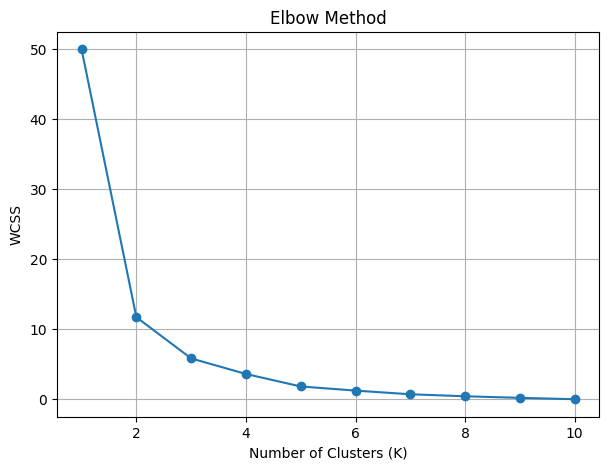

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [ ]:
print("\nSilhouette Scores:")
silhouette_scores = {}

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score
    print(f"K = {k}, Silhouette Score = {score:.4f}")
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nOptimal K based on Silhouette Score: {best_k}")


Silhouette Scores:
K = 2, Silhouette Score = 0.6073
K = 3, Silhouette Score = 0.5203
K = 4, Silhouette Score = 0.5134
K = 5, Silhouette Score = 0.4187
K = 6, Silhouette Score = 0.3034
K = 7, Silhouette Score = 0.2244
K = 8, Silhouette Score = 0.1736
K = 9, Silhouette Score = 0.0663

Optimal K based on Silhouette Score: 2


In [ ]:

#Apply K-Means with k = 3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [ ]:
print("\nCustomer Cluster Labels:")
print(df[['CustomerID', 'Cluster']])


Customer Cluster Labels:
   CustomerID  Cluster
0           1        2
1           2        1
2           3        0
3           4        0
4           5        1
5           6        0
6           7        2
7           8        2
8           9        0
9          10        1


In [ ]:
centroids_scaled = pd.DataFrame(kmeans_final.cluster_centers_, columns=X.columns)
print("\nCluster Centroids (Scaled):")
print(centroids_scaled)

centroids_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=X.columns
)
print("\nCluster Centroids (Original Scale):")
print(centroids_original)


Cluster Centroids (Scaled):
        Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  1.112373      1.109297      -1.093388       -1.083473      -0.951358
1 -0.926978     -0.956162       1.246943        1.123601       1.320251
2 -0.556187     -0.522901       0.210907        0.321029      -0.051775

Cluster Centroids (Original Scale):
         Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  51.000000  68750.000000          12.75        2.000000     157.500000
1  25.333333  22666.666667          76.00        5.666667     450.000000
2  30.000000  32333.333333          48.00        4.333333     273.333333


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print("\n=== Existing Customer Clusters ===")
print(df)
print("\nEnter NEW customer details:")
age = float(input("Age: "))
income = float(input("Annual Income (₹): "))
spending = float(input("Spending Score (1-100): "))
visits = float(input("Visits Per Month: "))
aov = float(input("Average Order Value: "))
new_customer = np.array([[age, income, spending, visits, aov]])
new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_customer_scaled)[0]
print("\nPredicted Cluster for New Customer:", predicted_cluster)
if predicted_cluster == 0:
    print("Segment: High-Value / Loyal Customers")
elif predicted_cluster == 1:
    print("Segment: Regular / Mid-Value Customers")
else:
    print("Segment: Low Engagement / At-Risk Customers")



=== Existing Customer Clusters ===
   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
0           1   22         15000             39               4   
1           2   25         18000             81               6   
2           3   47         60000              6               2   
3           4   52         65000             20               3   
4           5   23         20000             77               5   
5           6   45         70000             15               2   
6           7   33         40000             50               4   
7           8   35         42000             55               5   
8           9   60         80000             10               1   
9          10   28         30000             70               6   

   AvgOrderValue  Cluster  
0            200        2  
1            500        1  
2            150        0  
3            200        0  
4            450        1  
5            180        0  
6            300        2  
7 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
